In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from pathlib import Path

ROOT = Path("../")

with open(ROOT / "config.yaml", "r") as f:
    config = yaml.safe_load(f)

train_df = pd.read_csv(ROOT / config["paths"]["raw_train"], na_values=config["data"]["na_placeholder"], skiprows=20)
test_df = pd.read_csv(ROOT / config["paths"]["raw_test"], na_values=config["data"]["na_placeholder"], skiprows=20)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (60000, 171)
Test shape: (16000, 171)


In [5]:
print(train_df.head())
print("\nTarget distribution:\n", train_df["class"].value_counts())
print("\nTarget distribution (%):\n", train_df["class"].value_counts(normalize=True) * 100)

  class  aa_000  ab_000        ac_000  ad_000  ae_000  af_000  ag_000  ag_001  \
0   neg   76698     NaN  2.130706e+09   280.0     0.0     0.0     0.0     0.0   
1   neg   33058     NaN  0.000000e+00     NaN     0.0     0.0     0.0     0.0   
2   neg   41040     NaN  2.280000e+02   100.0     0.0     0.0     0.0     0.0   
3   neg      12     0.0  7.000000e+01    66.0     0.0    10.0     0.0     0.0   
4   neg   60874     NaN  1.368000e+03   458.0     0.0     0.0     0.0     0.0   

   ag_002  ...     ee_002    ee_003    ee_004    ee_005    ee_006    ee_007  \
0     0.0  ...  1240520.0  493384.0  721044.0  469792.0  339156.0  157956.0   
1     0.0  ...   421400.0  178064.0  293306.0  245416.0  133654.0   81140.0   
2     0.0  ...   277378.0  159812.0  423992.0  409564.0  320746.0  158022.0   
3     0.0  ...      240.0      46.0      58.0      44.0      10.0       0.0   
4     0.0  ...   622012.0  229790.0  405298.0  347188.0  286954.0  311560.0   

     ee_008  ee_009  ef_000  eg_000  


In [6]:
missing = train_df.isnull().sum()
missing_pct = (missing / len(train_df)) * 100
missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_df = missing_df[missing_df["missing_count"] > 0].sort_values("missing_pct", ascending=False)

print(f"Columns with missing values: {len(missing_df)} out of {train_df.shape[1]}")
print(missing_df.head(20))

Columns with missing values: 169 out of 171
        missing_count  missing_pct
br_000          49264    82.106667
bq_000          48722    81.203333
bp_000          47740    79.566667
bo_000          46333    77.221667
cr_000          46329    77.215000
ab_000          46329    77.215000
bn_000          44009    73.348333
bm_000          39549    65.915000
bl_000          27277    45.461667
bk_000          23034    38.390000
ad_000          14861    24.768333
cf_000          14861    24.768333
ch_000          14861    24.768333
cg_000          14861    24.768333
co_000          14861    24.768333
cy_000          13808    23.013333
cz_000          13808    23.013333
cx_000          13808    23.013333
cv_000          13808    23.013333
ct_000          13808    23.013333


In [7]:
print("Data types:\n", train_df.dtypes.value_counts())
print("\nTarget column dtype:", train_df["class"].dtype)
print("\nBasic statistics:")
train_df.describe()

Data types:
 float64    169
object       1
int64        1
Name: count, dtype: int64

Target column dtype: object

Basic statistics:


,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
count,6.000000e+04,13671.000000,5.666500e+04,4.513900e+04,57500.000000,57500.000000,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,...,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,57276.000000,57277.000000
mean,5.933650e+04,0.713189,3.560143e+08,1.906206e+05,6.819130,11.006817,2.216364e+02,9.757223e+02,8.606015e+03,8.859128e+04,...,4.454897e+05,2.111264e+05,4.457343e+05,3.939462e+05,3.330582e+05,3.462714e+05,1.387300e+05,8.388915e+03,0.090579,0.212756
std,1.454301e+05,3.478962,7.948749e+08,4.040441e+07,161.543373,209.792592,2.047846e+04,3.420053e+04,1.503220e+05,7.617312e+05,...,1.155540e+06,5.433188e+05,1.168314e+06,1.121044e+06,1.069160e+06,1.728056e+06,4.495100e+05,4.747043e+04,4.368855,8.830641
min,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,8.340000e+02,0.000000,1.600000e+01,2.400000e+01,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,2.936000e+03,1.166000e+03,2.700000e+03,3.584000e+03,5.120000e+02,1.100000e+02,0.000000e+00,0.000000e+00,0.000000,0.000000
50%,3.077600e+04,0.000000,1.520000e+02,1.260000e+02,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,2.337960e+05,1.120860e+05,2.215180e+05,1.899880e+05,9.243200e+04,4.109800e+04,3.812000e+03,0.000000e+00,0.000000,0.000000
75%,4.866800e+04,0.000000,9.640000e+02,4.300000e+02,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,4.383960e+05,2.182320e+05,4.666140e+05,4.032220e+05,2.750940e+05,1.678140e+05,1.397240e+05,2.028000e+03,0.000000,0.000000
max,2.746564e+06,204.000000,2.130707e+09,8.584298e+09,21050.000000,20070.000000,3.376892e+06,4.109372e+06,1.055286e+07,6.340207e+07,...,7.793393e+07,3.775839e+07,9.715238e+07,5.743524e+07,3.160781e+07,1.195801e+08,1.926740e+07,3.810078e+06,482.000000,1146.000000


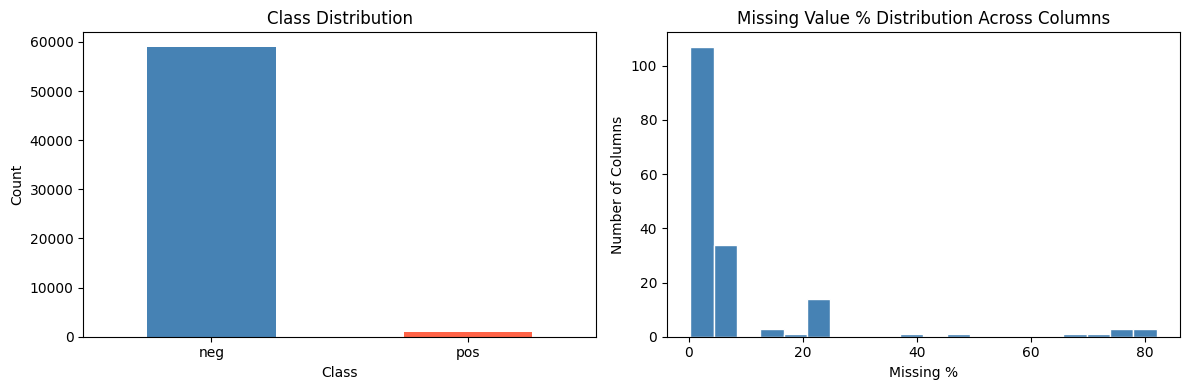

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution
train_df["class"].value_counts().plot(kind="bar", ax=axes[0], color=["steelblue", "tomato"])
axes[0].set_title("Class Distribution")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

# Missing value distribution
axes[1].hist(missing_df["missing_pct"], bins=20, color="steelblue", edgecolor="white")
axes[1].set_title("Missing Value % Distribution Across Columns")
axes[1].set_xlabel("Missing %")
axes[1].set_ylabel("Number of Columns")

plt.tight_layout()
plt.savefig("../reports/eda_class_and_missing.png", dpi=150, bbox_inches="tight")
plt.show()